# Chargement du csv dans Hadoop

- hdfs dfs -mkdir -p /projet/bronze /projet/silver /projet/gold
- hdfs dfs -put ai_student_impact_dataset.csv /projet/bronze/
- hdfs dfs -ls /projet/bronze

# Spark


In [24]:
import os
from dotenv import load_dotenv

load_dotenv() 
assert os.environ.get("JAVA_HOME"), "JAVA_HOME manquant : copie .env.example en .env et renseigne ton chemin JDK 17"
HDFS_URI = os.environ.get("HDFS_URI", "hdfs://localhost:9000")

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("ia-etudiants").getOrCreate()

### Bronze - Chargement 

In [25]:
df_spark = spark.read.csv(f"{HDFS_URI}/projet/bronze/ai_student_impact_dataset.csv", header=True, inferSchema=True)
df_spark.printSchema()
df_spark.show(5)
print(df_spark.count())

root
 |-- Student_ID: integer (nullable = true)
 |-- Major_Category: string (nullable = true)
 |-- Year_of_Study: string (nullable = true)
 |-- Pre_Semester_GPA: double (nullable = true)
 |-- Weekly_GenAI_Hours: double (nullable = true)
 |-- Primary_Use_Case: string (nullable = true)
 |-- Prompt_Engineering_Skill: string (nullable = true)
 |-- Tool_Diversity: integer (nullable = true)
 |-- Paid_Subscription: boolean (nullable = true)
 |-- Traditional_Study_Hours: double (nullable = true)
 |-- Perceived_AI_Dependency: integer (nullable = true)
 |-- Institutional_Policy: string (nullable = true)
 |-- Anxiety_Level_During_Exams: integer (nullable = true)
 |-- Post_Semester_GPA: double (nullable = true)
 |-- Skill_Retention_Score: double (nullable = true)
 |-- Burnout_Risk_Level: string (nullable = true)

+----------+--------------+-------------+----------------+------------------+--------------------+------------------------+--------------+-----------------+-----------------------+-------

### Silver - Nettoyage et visualisation

In [26]:
# Doublons (lignes completes)
print(f"Lignes: {df_spark.count()} | apres dropDuplicates: {df_spark.dropDuplicates().count()}")

Lignes: 50000 | apres dropDuplicates: 50000


In [27]:
# Passage en pandas (50k lignes, ca tient en memoire)
df = df_spark.toPandas()

In [28]:
# Valeurs manquantes + coherence de domaine
print(df.isnull().sum())

domain_checks = {
    "Pre_Semester_GPA": (0, 4), "Post_Semester_GPA": (0, 4),
    "Tool_Diversity": (1, 5), "Perceived_AI_Dependency": (1, 10), "Anxiety_Level_During_Exams": (1, 10),
}
for c, (lo, hi) in domain_checks.items():
    n = ((df[c] < lo) | (df[c] > hi)).sum()
    print(f"{c} hors [{lo},{hi}]: {n}")

n_heures = ((df["Weekly_GenAI_Hours"] + df["Traditional_Study_Hours"]) > 168).sum()
print(f"Heures/semaine > 168h: {n_heures}")

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64
Pre_Semester_GPA hors [0,4]: 0
Post_Semester_GPA hors [0,4]: 0
Tool_Diversity hors [1,5]: 0
Perceived_AI_Dependency hors [1,10]: 0
Anxiety_Level_During_Exams hors [1,10]: 0
Heures/semaine > 168h: 0


In [29]:
# Valeurs distinctes des colonnes categorielles (typos / casse)
categorical_cols = ["Major_Category", "Year_of_Study", "Primary_Use_Case",
                     "Prompt_Engineering_Skill", "Institutional_Policy", "Burnout_Risk_Level"]

for c in categorical_cols:
    print(f"--- {c} ---")
    df_spark.groupBy(c).count().orderBy(c).show(truncate=False)

--- Major_Category ---
+--------------+-----+
|Major_Category|count|
+--------------+-----+
|Arts          |5933 |
|Business      |12538|
|Humanities    |9994 |
|Medical       |6476 |
|STEM          |15059|
+--------------+-----+

--- Year_of_Study ---
+-------------+-----+
|Year_of_Study|count|
+-------------+-----+
|Freshman     |11031|
|Graduate     |7430 |
|Junior       |11045|
|Senior       |10634|
|Sophomore    |9860 |
+-------------+-----+

--- Primary_Use_Case ---
+-------------------------+-----+
|Primary_Use_Case         |count|
+-------------------------+-----+
|Copywriting/Drafting     |12011|
|Debugging/Troubleshooting|12295|
|Direct_Answer_Generation |6340 |
|Ideation                 |10721|
|Summarizing_Reading      |8633 |
+-------------------------+-----+

--- Prompt_Engineering_Skill ---
+------------------------+-----+
|Prompt_Engineering_Skill|count|
+------------------------+-----+
|Advanced                |13809|
|Beginner                |18495|
|Intermediate     

In [30]:
# Statistiques descriptives
numeric_cols = ["Pre_Semester_GPA", "Weekly_GenAI_Hours", "Tool_Diversity",
                 "Traditional_Study_Hours", "Perceived_AI_Dependency",
                 "Anxiety_Level_During_Exams", "Post_Semester_GPA", "Skill_Retention_Score"]

df_spark.select(numeric_cols).summary().show()

+-------+------------------+------------------+------------------+-----------------------+-----------------------+--------------------------+------------------+---------------------+
|summary|  Pre_Semester_GPA|Weekly_GenAI_Hours|    Tool_Diversity|Traditional_Study_Hours|Perceived_AI_Dependency|Anxiety_Level_During_Exams| Post_Semester_GPA|Skill_Retention_Score|
+-------+------------------+------------------+------------------+-----------------------+-----------------------+--------------------------+------------------+---------------------+
|  count|             50000|             50000|             50000|                  50000|                  50000|                     50000|             50000|                50000|
|   mean|3.1461023400000303| 8.427752200000038|           2.80026|     11.209271000000108|                3.50536|                   4.27076|        3.34929942|    75.79812500000035|
| stddev|0.4788543560796032| 8.269489724680785|1.1880202692897102|      5.15642607133

#### Visualisations

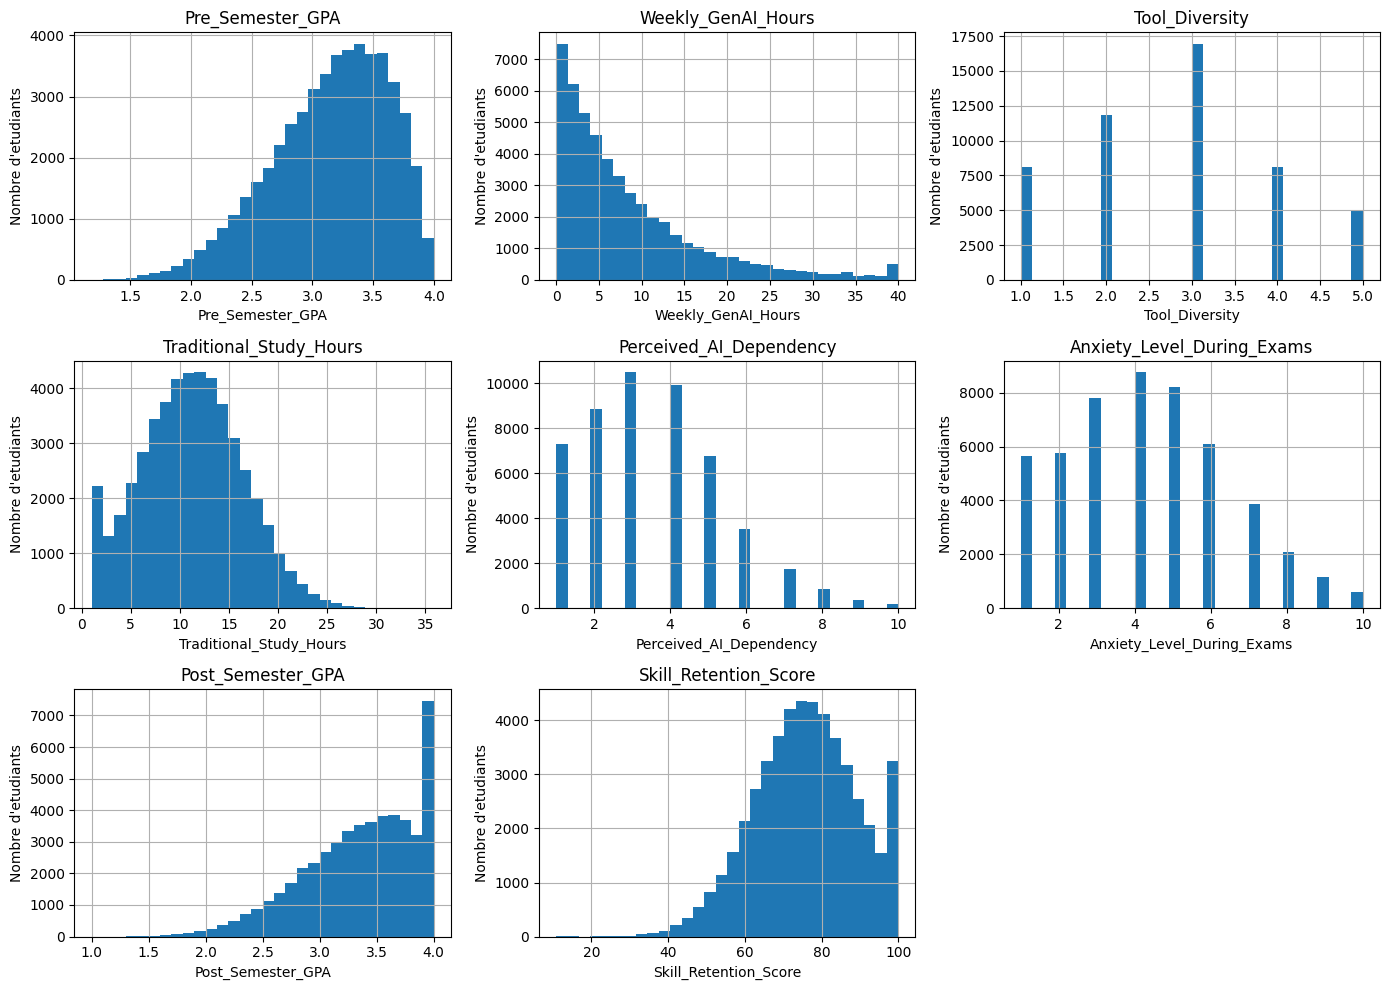

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

axes = df[numeric_cols].hist(figsize=(14, 10), bins=30)
for ax in axes.flat:
    ax.set_xlabel(ax.get_title())
    ax.set_ylabel("Nombre d'etudiants")
plt.tight_layout()
plt.show()

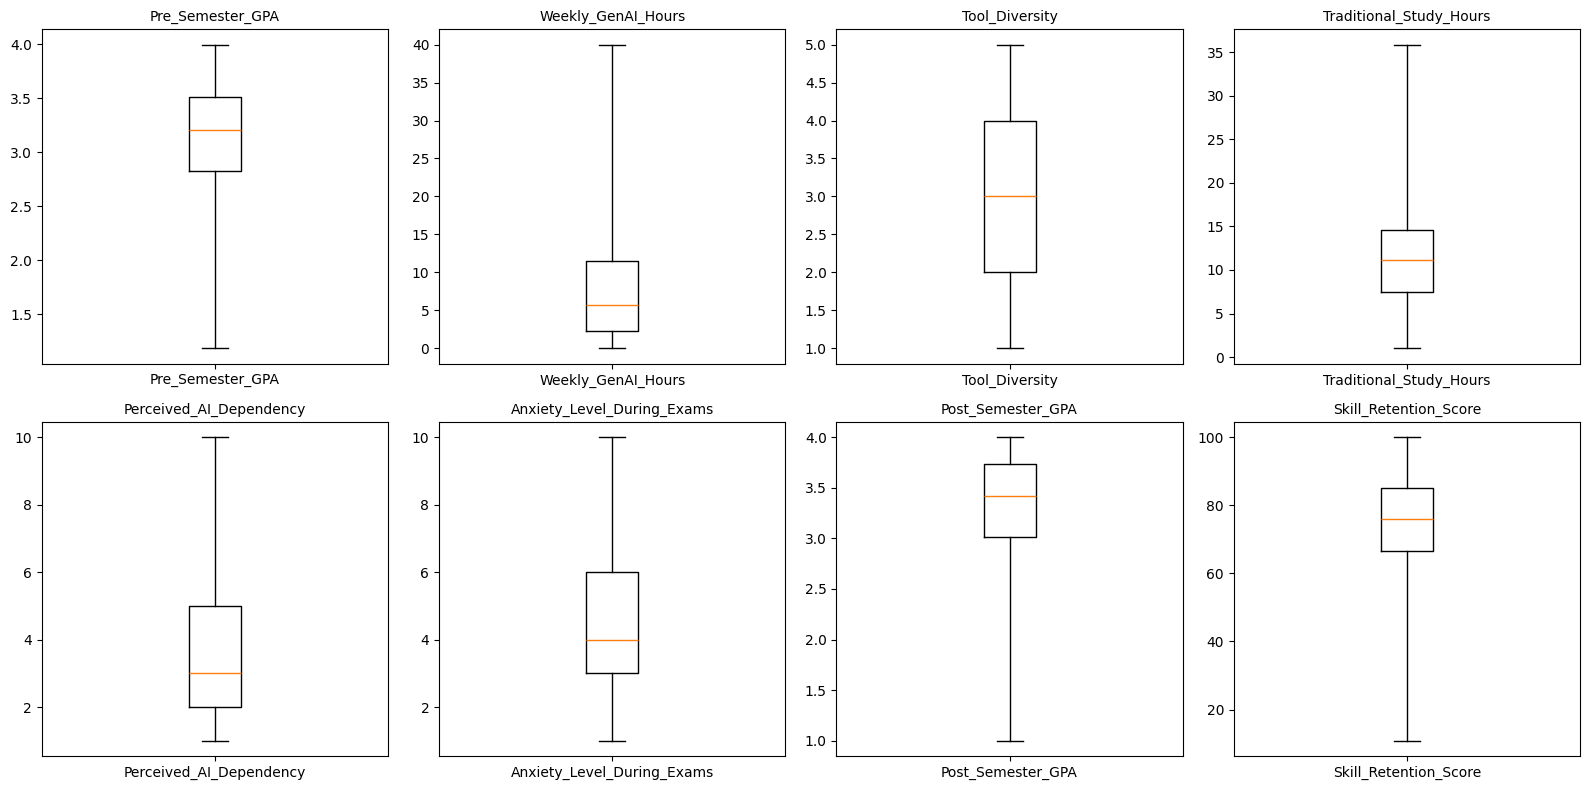

In [32]:
# Boite a moustache par colonne (echelles differentes)
from pyspark.sql import functions as F

quantiles = df_spark.approxQuantile(numeric_cols, [0.25, 0.5, 0.75], 0.01)
bounds = df_spark.agg(*[F.min(c).alias(f"{c}_min") for c in numeric_cols],
                       *[F.max(c).alias(f"{c}_max") for c in numeric_cols]).first()

stats = [
    {"label": c, "q1": q1, "med": med, "q3": q3,
     "whislo": bounds[f"{c}_min"], "whishi": bounds[f"{c}_max"]}
    for c, (q1, med, q3) in zip(numeric_cols, quantiles)
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, stat in zip(axes.flat, stats):
    ax.bxp([stat], showfliers=False)
    ax.set_title(stat["label"], fontsize=10)
plt.tight_layout()
plt.show()

In [33]:
# Quantification des valeurs aberrantes (regle IQR de Tukey)
for c, (q1, med, q3) in zip(numeric_cols, quantiles):
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df_spark.filter((F.col(c) < lo) | (F.col(c) > hi)).count()
    print(f"{c}: {outliers} valeurs aberrantes")

Pre_Semester_GPA: 339 valeurs aberrantes
Weekly_GenAI_Hours: 2725 valeurs aberrantes
Tool_Diversity: 0 valeurs aberrantes
Traditional_Study_Hours: 200 valeurs aberrantes
Perceived_AI_Dependency: 190 valeurs aberrantes
Anxiety_Level_During_Exams: 0 valeurs aberrantes
Post_Semester_GPA: 346 valeurs aberrantes
Skill_Retention_Score: 216 valeurs aberrantes


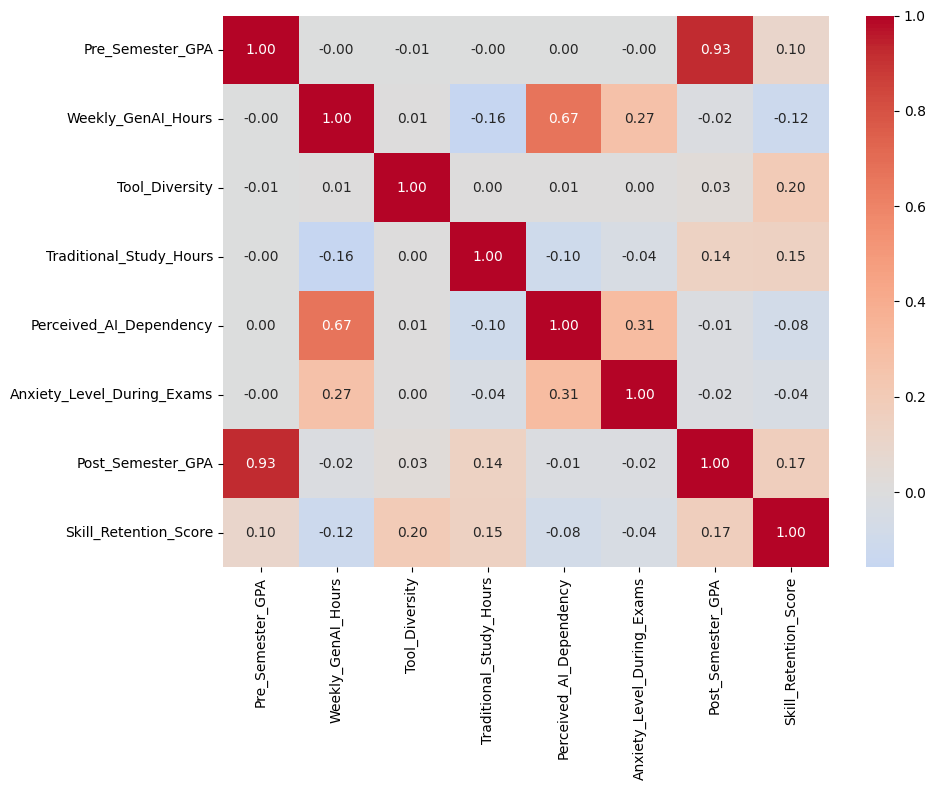

In [34]:
# Correlation entre variables numeriques
corr = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.tight_layout()
plt.show()

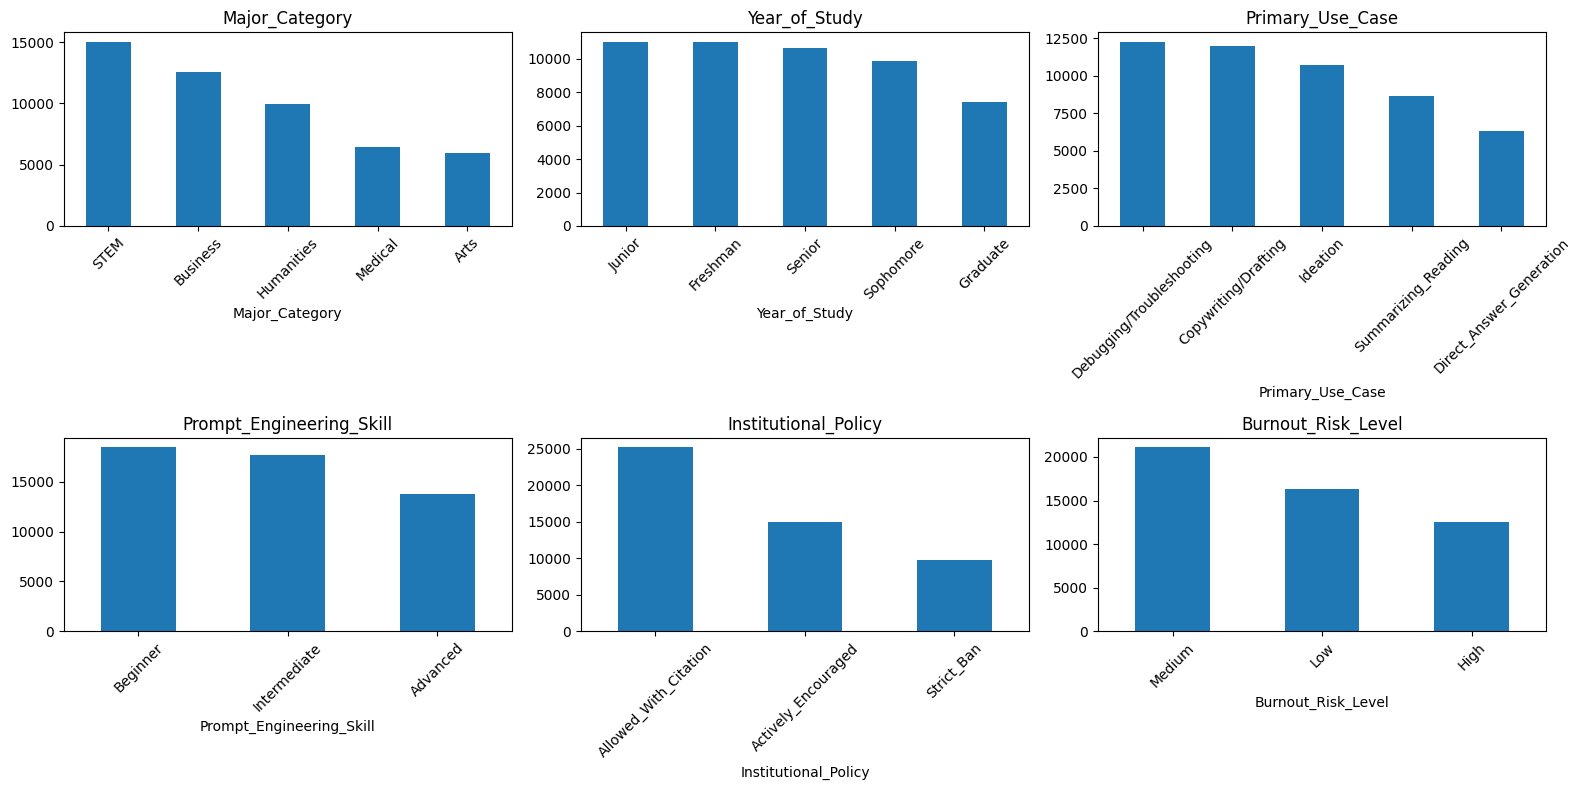

In [35]:
# Repartition des variables categorielles
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.flat, categorical_cols):
    df[c].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(c)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [36]:
# Ecriture Silver en parquet (aucune anomalie detectee, aucune ligne supprimee)
df_spark.write.mode("overwrite").parquet(f"{HDFS_URI}/projet/silver/ai_student_impact_clean.parquet")

### Gold - Feature engineering

In [37]:
# Lecture depuis Silver
df_silver = spark.read.parquet(f"{HDFS_URI}/projet/silver/ai_student_impact_clean.parquet")

In [ ]:
# Variation de GPA sur le semestre + encodage numerique des colonnes ordinales
from pyspark.sql import functions as F

df_gold = (df_silver
    .withColumn("GPA_Delta", F.col("Post_Semester_GPA") - F.col("Pre_Semester_GPA"))
    .withColumn("Paid_Subscription_Int", F.col("Paid_Subscription").cast("int"))
    .withColumn("Year_of_Study_Ord", F.when(F.col("Year_of_Study") == "Freshman", 1)
                                       .when(F.col("Year_of_Study") == "Sophomore", 2)
                                       .when(F.col("Year_of_Study") == "Junior", 3)
                                       .when(F.col("Year_of_Study") == "Senior", 4)
                                       .when(F.col("Year_of_Study") == "Graduate", 5))

    .withColumn("Prompt_Engineering_Skill_Ord", F.when(F.col("Prompt_Engineering_Skill") == "Beginner", 1)
                                                   .when(F.col("Prompt_Engineering_Skill") == "Intermediate", 2)
                                                   .when(F.col("Prompt_Engineering_Skill") == "Advanced", 3))

                                                   
    .withColumn("Institutional_Policy_Ord", F.when(F.col("Institutional_Policy") == "Strict_Ban", 1)
                                               .when(F.col("Institutional_Policy") == "Allowed_With_Citation", 2)
                                               .when(F.col("Institutional_Policy") == "Actively_Encouraged", 3))
)

df_gold.select("Student_ID", "GPA_Delta", "Paid_Subscription_Int", "Year_of_Study_Ord",
               "Prompt_Engineering_Skill_Ord", "Institutional_Policy_Ord").show(5)

+----------+--------------------+---------------------+-----------------+----------------------------+------------------------+
|Student_ID|           GPA_Delta|Paid_Subscription_Int|Year_of_Study_Ord|Prompt_Engineering_Skill_Ord|Institutional_Policy_Ord|
+----------+--------------------+---------------------+-----------------+----------------------------+------------------------+
|    100001|-0.02500000000000...|                    1|                4|                           1|                       2|
|    100002|              -0.125|                    0|                3|                           3|                       2|
|    100003| 0.10099999999999998|                    0|                1|                           1|                       1|
|    100004| 0.21099999999999985|                    0|                4|                           2|                       2|
|    100005| 0.16300000000000026|                    0|                2|                           3|  

In [39]:
# Ecriture Gold (parquet)
df_gold.write.mode("overwrite").parquet(f"{HDFS_URI}/projet/gold/ai_student_impact_features.parquet")

### Gold - Analyse : qu'est-ce qui fait varier la note ? (GPA_Delta)

On cherche quels criteres expliquent la variation de note sur le semestre
(GPA_Delta = Post_Semester_GPA - Pre_Semester_GPA).

count    50000.000
mean         0.203
std          0.187
min         -0.924
25%          0.087
50%          0.204
75%          0.325
max          1.008
Name: GPA_Delta, dtype: float64


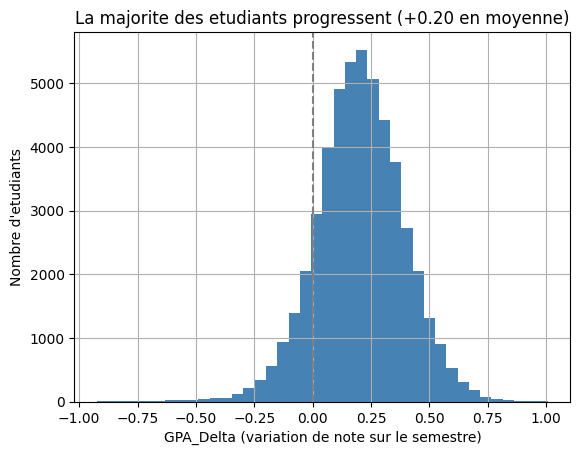

In [40]:
# Passage du gold en pandas pour l'analyse
gold = df_gold.toPandas()

print(gold["GPA_Delta"].describe().round(3))

gold["GPA_Delta"].hist(bins=40, color="steelblue")
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("GPA_Delta (variation de note sur le semestre)")
plt.ylabel("Nombre d'etudiants")
plt.title("La majorite des etudiants progressent (+0.20 en moyenne)")
plt.show()

Pre_Semester_GPA               -0.104
Weekly_GenAI_Hours             -0.046
Anxiety_Level_During_Exams     -0.040
Perceived_AI_Dependency        -0.039
Paid_Subscription_Int           0.017
Institutional_Policy_Ord        0.030
Tool_Diversity                  0.081
Prompt_Engineering_Skill_Ord    0.127
Skill_Retention_Score           0.196
Year_of_Study_Ord               0.233
Traditional_Study_Hours         0.376
Name: GPA_Delta, dtype: float64


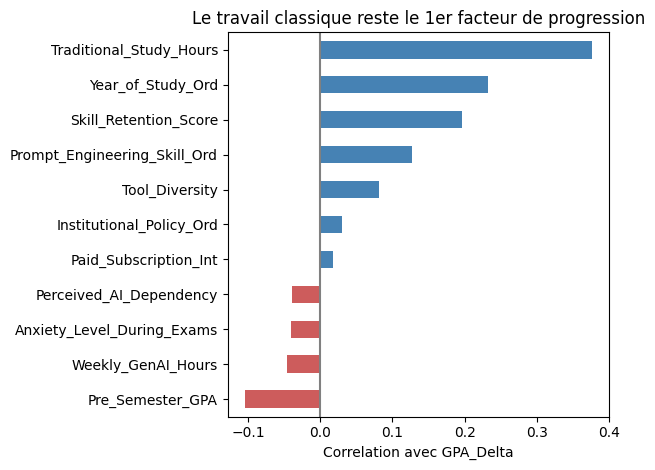

In [41]:
# Correlation de chaque facteur avec GPA_Delta
facteurs = ["Weekly_GenAI_Hours", "Traditional_Study_Hours", "Perceived_AI_Dependency",
            "Anxiety_Level_During_Exams", "Tool_Diversity", "Skill_Retention_Score",
            "Pre_Semester_GPA", "Paid_Subscription_Int", "Year_of_Study_Ord",
            "Prompt_Engineering_Skill_Ord", "Institutional_Policy_Ord"]

corr_delta = gold[facteurs + ["GPA_Delta"]].corr()["GPA_Delta"].drop("GPA_Delta").sort_values()
print(corr_delta.round(3))

couleurs = ["indianred" if v < 0 else "steelblue" for v in corr_delta]
corr_delta.plot(kind="barh", color=couleurs)
plt.axvline(0, color="gray")
plt.xlabel("Correlation avec GPA_Delta")
plt.title("Le travail classique reste le 1er facteur de progression")
plt.tight_layout()
plt.show()

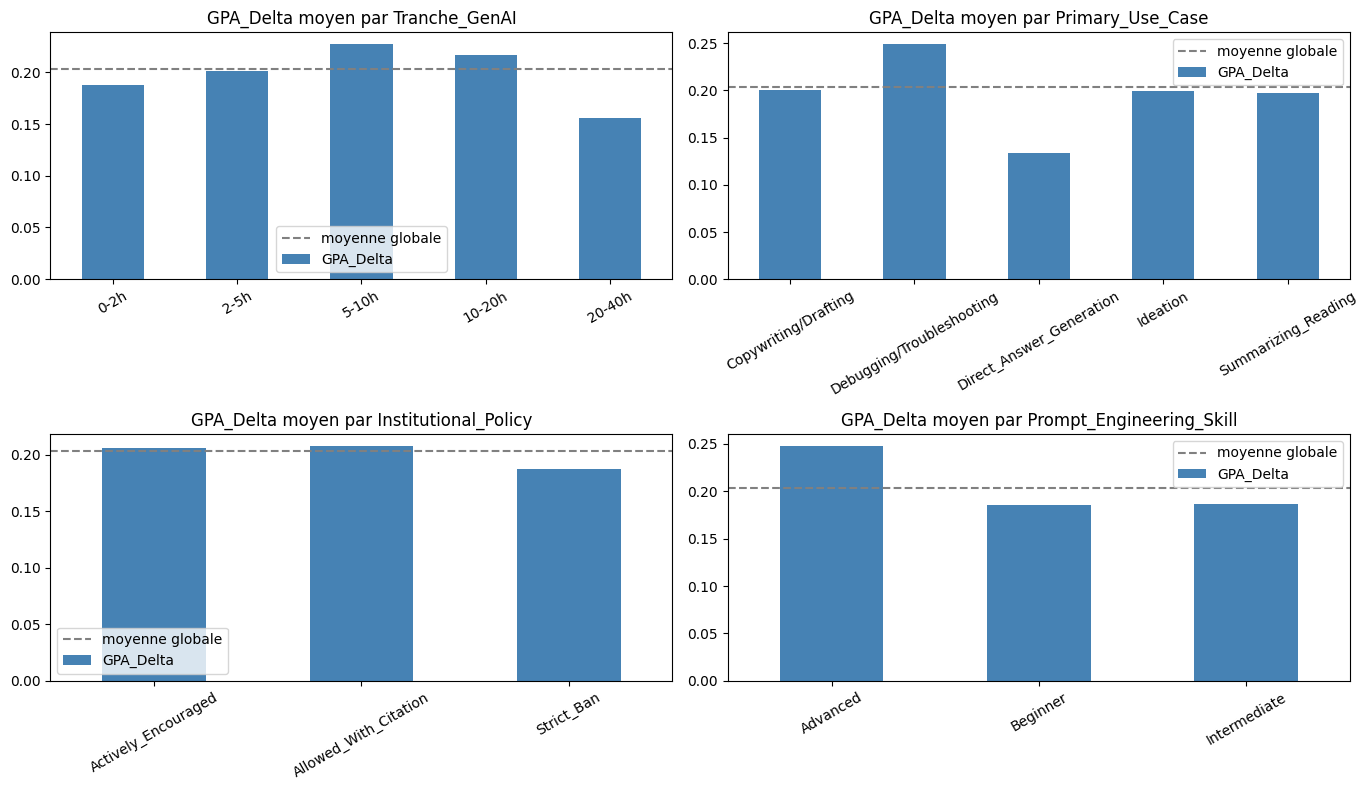

In [42]:
# GPA_Delta moyen par groupe
import pandas as pd

gold["Tranche_GenAI"] = pd.cut(gold["Weekly_GenAI_Hours"], bins=[0, 2, 5, 10, 20, 40],
                               labels=["0-2h", "2-5h", "5-10h", "10-20h", "20-40h"], include_lowest=True)

groupes = ["Tranche_GenAI", "Primary_Use_Case", "Institutional_Policy", "Prompt_Engineering_Skill"]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, c in zip(axes.flat, groupes):
    gold.groupby(c, observed=True)["GPA_Delta"].mean().plot(kind="bar", ax=ax, color="steelblue")
    ax.axhline(gold["GPA_Delta"].mean(), color="gray", linestyle="--", label="moyenne globale")
    ax.set_title(f"GPA_Delta moyen par {c}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.legend()
plt.tight_layout()
plt.show()

**Ce qu'on observe :**
- En moyenne les etudiants progressent de **+0.20 point de GPA** sur le semestre.
- Le 1er facteur de progression reste **le travail personnel classique** (correlation +0.38),
  devant l'annee d'etude (+0.23) et la retention des competences (+0.20).
- Le volume d'heures d'IA n'a presque aucun effet global (-0.05), mais en detail :
  usage modere (5-10h) = meilleure progression (+0.23), usage intensif (20-40h) = la pire (+0.16).
- **C'est le type d'usage qui compte** : Debugging (+0.25) > Ideation/Copywriting/Resume (+0.20)
  > Direct_Answer_Generation (+0.13). Demander directement les reponses a l'IA est le seul
  usage nettement penalisant.
- Un bon niveau de prompt engineering (Advanced +0.25) va avec une meilleure progression.

### ML - Kmeans
